In [1]:
!pip install datasets -q
!pip install langdetect -q
!pip install indic-nlp-library -q
!pip install pandas numpy matplotlib seaborn -q
!pip install tqdm -q

print("✅ All libraries installed successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 21.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 7.7 MB/s eta 0:00:00
✅ All libraries installed successfully


In [2]:
# Cell 2: Load BnSentMix dataset from HuggingFace
from datasets import load_dataset
import pandas as pd

print("Loading BnSentMix...")
bnsent = load_dataset("aplycaebous/BnSentMix")

# Convert to pandas
bnsent_df = pd.DataFrame(bnsent['train'])

# Preview
print(f"\n✅ BnSentMix loaded: {len(bnsent_df)} rows")
print(f"Columns: {list(bnsent_df.columns)}")
print(f"\nFirst 3 rows:")
bnsent_df.head(3)

Loading BnSentMix...


README.md: 0.00B [00:00, ?B/s]

dataset.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/20015 [00:00<?, ? examples/s]


✅ BnSentMix loaded: 20015 rows
Columns: ['Sentence', 'Label']

First 3 rows:


,Sentence,Label
0,Youtube ar volg gula boring hoia jaitase din d...,3
1,"Your video making, camera work is really good....",3
2,You made me nostalgic. College life a ei dokan...,3


In [3]:
# Cell 3 (Final): Load 3 verified datasets one by one with error handling

additional_dfs = []

# --- Dataset 2: Swarnadeep Bengali Code-Mix Sentiment ---
try:
    print("Loading bn_code_mix_sentiment_dataset...")
    ds2 = load_dataset("Swarnadeep-28/bn_code_mix_sentiment_dataset")
    df2 = pd.DataFrame(ds2['train'])
    print(f"✅ Loaded: {len(df2)} rows | Columns: {list(df2.columns)}")
    additional_dfs.append(('bn_code_mix', df2))
except Exception as e:
    print(f"❌ Failed: {e}")

# --- Dataset 3: Bengali Hate Speech ---
try:
    print("\nLoading Banglahatespeech...")
    ds3 = load_dataset("FariaAFrinTisha/Banglahatespeech")
    df3 = pd.DataFrame(ds3['train'])
    print(f"✅ Loaded: {len(df3)} rows | Columns: {list(df3.columns)}")
    additional_dfs.append(('hate_speech', df3))
except Exception as e:
    print(f"❌ Failed: {e}")

# --- Dataset 4: Bengali Fake Reviews ---
try:
    print("\nLoading Bengali-Fake-Review-Dataset...")
    ds4 = load_dataset("shawon95/Bengali-Fake-Review-Dataset")
    df4 = pd.DataFrame(ds4['train'])
    print(f"✅ Loaded: {len(df4)} rows | Columns: {list(df4.columns)}")
    additional_dfs.append(('fake_reviews', df4))
except Exception as e:
    print(f"❌ Failed: {e}")

# Summary
print(f"\n{'='*40}")
print(f"BnSentMix:        {len(bnsent_df):>7} rows  ✅")
for name, df in additional_dfs:
    print(f"{name:<18}: {len(df):>7} rows  ✅")
total = len(bnsent_df) + sum(len(df) for _, df in additional_dfs)
print(f"{'='*40}")
print(f"TOTAL SO FAR:     {total:>7} rows")

Loading bn_code_mix_sentiment_dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/821k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/99.5k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/108k [00:00<?, ?B/s]

...

README.md: 0.00B [00:00, ?B/s]

fake.csv: 0.00B [00:00, ?B/s]

non-fake.csv:   0%|          | 0.00/12.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9049 [00:00<?, ? examples/s]

✅ Loaded: 9049 rows | Columns: ['Review', 'Label']

BnSentMix:          20015 rows  ✅
bn_code_mix       :   16012 rows  ✅
hate_speech       :   30000 rows  ✅
fake_reviews      :    9049 rows  ✅
TOTAL SO FAR:       75076 rows


In [4]:
# Cell 4: Standardize all datasets into unified format

# We need two columns only:
# 'text'   → the actual sentence
# 'source' → where it came from (for tracking)

# --- Standardize BnSentMix ---
df1_std = pd.DataFrame({
    'text'  : bnsent_df['Sentence'],
    'source': 'bnsentmix'
})

# --- Standardize bn_code_mix ---
# Already has 'text' column
df2_std = pd.DataFrame({
    'text'  : df2['text'],
    'source': 'bn_code_mix'
})

# --- Standardize hate_speech ---
# Text is in 'sentence' column
df3_std = pd.DataFrame({
    'text'  : df3['sentence'],
    'source': 'hate_speech'
})

# --- Standardize fake_reviews ---
# Text is in 'Review' column
df4_std = pd.DataFrame({
    'text'  : df4['Review'],
    'source': 'fake_reviews'
})

# --- Combine all ---
combined_df = pd.concat(
    [df1_std, df2_std, df3_std, df4_std],
    ignore_index=True
)

print(f"✅ Combined dataset: {len(combined_df)} rows")
print(f"Columns: {list(combined_df.columns)}")
print(f"\nSource distribution:")
print(combined_df['source'].value_counts())
print(f"\nSample rows from each source:")
for source in combined_df['source'].unique():
    sample = combined_df[combined_df['source']==source].iloc[0]['text']
    print(f"\n[{source}]:\n  {sample[:100]}")

✅ Combined dataset: 75076 rows
Columns: ['text', 'source']

Source distribution:
source
hate_speech     30000
bnsentmix       20015
bn_code_mix     16012
fake_reviews     9049
Name: count, dtype: int64

Sample rows from each source:

[bnsentmix]:
  Youtube ar volg gula boring hoia jaitase din din. Onk din por ai volg ta dakhe val laglo

[bn_code_mix]:
  Alom bro and shapon bro nice Combination apnara chaila subscribe korta paren

[hate_speech]:
  যত্তসব পাপন শালার ফাজলামী!!!!!

[fake_reviews]:
  ।।।।।।।।।।।।Buy one get one Mexican  পাস্তা।।।।।।।।।।
গোপি আর কোকিলার  খালি কুকার এর ঝামেলা বাদ দিয়ে


In [5]:
# Cell 5: Data Cleaning Pipeline
import re
import unicodedata
from tqdm import tqdm

def clean_text(text):
    """
    Full cleaning pipeline for Bengali-English code-mixed text.
    Preserves Bengali script, English, and Romanized Bengali.
    """
    if not isinstance(text, str):
        return None
    
    # Step 1: Unicode normalization (NFC)
    # Ensures Bengali characters are in consistent composed form
    text = unicodedata.normalize('NFC', text)
    
    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Step 3: Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Step 4: Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    
    # Step 5: Remove excessive punctuation (keep single instances)
    # e.g. "!!!!!" → "!"  "।।।।" → "।"
    text = re.sub(r'([!?।,.]){2,}', r'\1', text)
    
    # Step 6: Remove special characters but KEEP:
    # Bengali Unicode range: \u0980-\u09FF
    # English letters, digits, basic punctuation
    text = re.sub(r'[^\u0980-\u09FF a-zA-Z0-9\s.,!?\'\"।-]', ' ', text)
    
    # Step 7: Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text if len(text) > 0 else None


# Apply cleaning with progress bar
tqdm.pandas(desc="Cleaning text")
combined_df['text_clean'] = combined_df['text'].progress_apply(clean_text)

# Report
total_before = len(combined_df)
combined_df = combined_df.dropna(subset=['text_clean']).reset_index(drop=True)
total_after = len(combined_df)

print(f"✅ Cleaning complete")
print(f"   Before : {total_before:,} rows")
print(f"   Removed: {total_before - total_after:,} rows (empty/null after cleaning)")
print(f"   After  : {total_after:,} rows")

print(f"\nSample cleaned rows:")
for source in combined_df['source'].unique():
    original = combined_df[combined_df['source']==source].iloc[0]['text']
    cleaned  = combined_df[combined_df['source']==source].iloc[0]['text_clean']
    print(f"\n[{source}]")
    print(f"  BEFORE: {original[:100]}")
    print(f"  AFTER : {cleaned[:100]}")

Cleaning text: 100%|██████████| 75076/75076 [00:03<00:00, 22421.94it/s]

✅ Cleaning complete
   Before : 75,076 rows
   Removed: 10 rows (empty/null after cleaning)
   After  : 75,066 rows

Sample cleaned rows:

[bnsentmix]
  BEFORE: Youtube ar volg gula boring hoia jaitase din din. Onk din por ai volg ta dakhe val laglo
  AFTER : Youtube ar volg gula boring hoia jaitase din din. Onk din por ai volg ta dakhe val laglo

[bn_code_mix]
  BEFORE: Alom bro and shapon bro nice Combination apnara chaila subscribe korta paren
  AFTER : Alom bro and shapon bro nice Combination apnara chaila subscribe korta paren

[hate_speech]
  BEFORE: যত্তসব পাপন শালার ফাজলামী!!!!!
  AFTER : যত্তসব পাপন শালার ফাজলামী!

[fake_reviews]
  BEFORE: ।।।।।।।।।।।।Buy one get one Mexican  পাস্তা।।।।।।।।।।
গোপি আর কোকিলার  খালি কুকার এর ঝামেলা বাদ দিয়ে
  AFTER : ।Buy one get one Mexican পাস্তা। গোপি আর কোকিলার খালি কুকার এর ঝামেলা বাদ দিয়ে আসুন আমরা পাস্তা খাই


Length distribution BEFORE filtering:
count    75066.00000
mean        24.40182
std         45.20214
min          1.00000
25%          6.00000
50%         10.00000
75%         20.00000
max       1305.00000
Name: token_count, dtype: float64

Length filtering:
   Before : 75,066 rows
   Removed: 14,067 rows
   After  : 60,999 rows

Deduplication:
   Before : 60,999 rows
   Removed: 14,630 duplicates
   After  : 46,369 rows


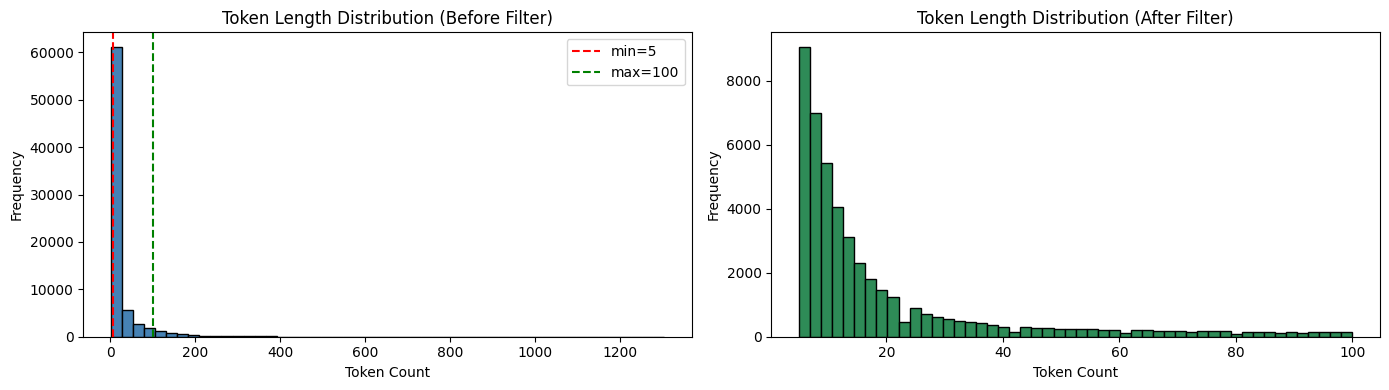


✅ Final clean corpus: 46,369 rows
Source distribution after cleaning:
source
hate_speech     23373
bnsentmix       17737
fake_reviews     5259
Name: count, dtype: int64


In [6]:
# Cell 6: Length Filtering + Deduplication

# --- Step 1: Add token length column ---
combined_df['token_count'] = combined_df['text_clean'].apply(lambda x: len(x.split()))

# --- Step 2: Length distribution BEFORE filtering ---
print("Length distribution BEFORE filtering:")
print(combined_df['token_count'].describe())

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(combined_df['token_count'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Token Length Distribution (Before Filter)')
axes[0].set_xlabel('Token Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=5,   color='red',   linestyle='--', label='min=5')
axes[0].axvline(x=100, color='green', linestyle='--', label='max=100')
axes[0].legend()

# --- Step 3: Apply length filter ---
# Keep sentences between 5 and 100 tokens
# Too short = not enough context for contrastive learning
# Too long  = slow training, likely multi-sentence noise
before_len = len(combined_df)
combined_df = combined_df[
    (combined_df['token_count'] >= 5) &
    (combined_df['token_count'] <= 100)
].reset_index(drop=True)
after_len = len(combined_df)

print(f"\nLength filtering:")
print(f"   Before : {before_len:,} rows")
print(f"   Removed: {before_len - after_len:,} rows")
print(f"   After  : {after_len:,} rows")

# --- Step 4: Deduplication ---
before_dedup = len(combined_df)
combined_df = combined_df.drop_duplicates(
    subset='text_clean'
).reset_index(drop=True)
after_dedup = len(combined_df)

print(f"\nDeduplication:")
print(f"   Before : {before_dedup:,} rows")
print(f"   Removed: {before_dedup - after_dedup:,} duplicates")
print(f"   After  : {after_dedup:,} rows")

# --- Step 5: Plot AFTER filtering ---
axes[1].hist(combined_df['token_count'], bins=50, color='seagreen', edgecolor='black')
axes[1].set_title('Token Length Distribution (After Filter)')
axes[1].set_xlabel('Token Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Final clean corpus: {len(combined_df):,} rows")
print(f"Source distribution after cleaning:")
print(combined_df['source'].value_counts())

Calculating CMI: 100%|██████████| 46369/46369 [00:01<00:00, 30323.43it/s]


CMI Score Distribution:
count    46369.000000
mean         0.017888
std          0.068091
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.500000
Name: cmi, dtype: float64

Dominant Language Distribution:
dominant_lang
BN_DOM      28008
EN_DOM      18335
BALANCED       26
Name: count, dtype: int64

CMI Buckets:
cmi_bucket
monolingual(0-0.1)    43487
low-mix(0.1-0.2)       1170
mid-mix(0.2-0.35)      1031
high-mix(0.35-0.5)      681
Name: count, dtype: int64


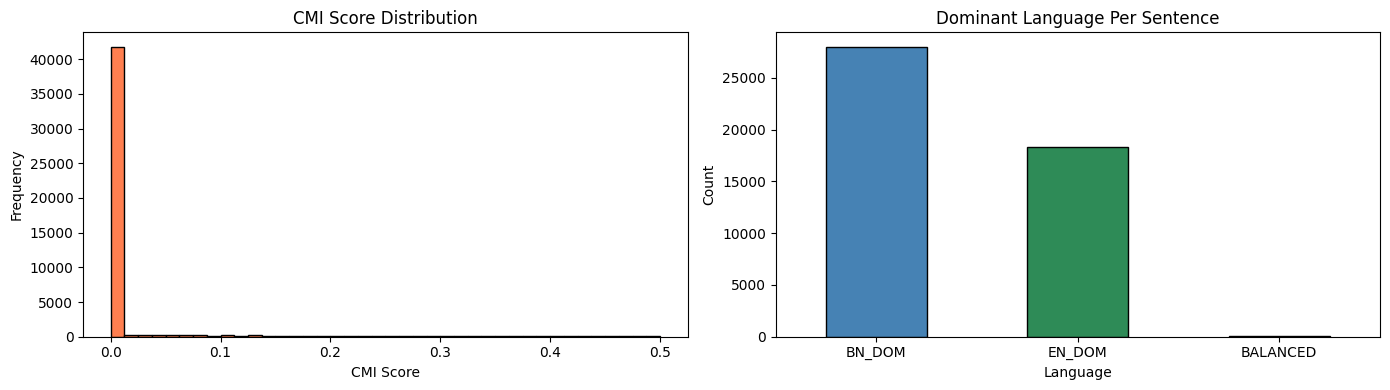


✅ CMI calculation complete
Mean CMI: 0.0179
Sentences with CMI > 0.1 (genuinely code-mixed): 2,882 (6.2%)


In [7]:
# Cell 7: Calculate Code-Mixing Index (CMI) per sentence

def detect_script(token):
    """
    Detect the script of a single token.
    Returns: 'BN' (Bengali), 'EN' (English/Latin), 'NUM' (number), 'OTHER'
    """
    bn_chars = sum(1 for c in token if '\u0980' <= c <= '\u09FF')
    en_chars = sum(1 for c in token if c.isascii() and c.isalpha())
    
    if bn_chars > 0 and en_chars == 0:
        return 'BN'
    elif en_chars > 0 and bn_chars == 0:
        return 'EN'
    elif token.isdigit():
        return 'NUM'
    else:
        return 'OTHER'

def calculate_cmi(text):
    """
    Calculate Code-Mixing Index for a sentence.
    CMI = 1 - (max_lang_tokens / total_lang_tokens)
    CMI = 0   → purely monolingual
    CMI = 0.5 → perfectly balanced code-mix
    """
    tokens = text.split()
    
    tag_counts = {'BN': 0, 'EN': 0, 'NUM': 0, 'OTHER': 0}
    for token in tokens:
        tag = detect_script(token)
        tag_counts[tag] += 1
    
    # Only count BN and EN for CMI
    lang_tokens = tag_counts['BN'] + tag_counts['EN']
    
    if lang_tokens == 0:
        return 0.0
    
    max_lang = max(tag_counts['BN'], tag_counts['EN'])
    cmi = 1 - (max_lang / lang_tokens)
    
    return round(cmi, 4)

def get_dominant_lang(text):
    """Return dominant language of sentence"""
    tokens = text.split()
    bn = sum(1 for t in tokens if detect_script(t) == 'BN')
    en = sum(1 for t in tokens if detect_script(t) == 'EN')
    if bn == 0 and en == 0:
        return 'OTHER'
    if bn > en:
        return 'BN_DOM'
    elif en > bn:
        return 'EN_DOM'
    else:
        return 'BALANCED'

# Apply CMI calculation
tqdm.pandas(desc="Calculating CMI")
combined_df['cmi']           = combined_df['text_clean'].progress_apply(calculate_cmi)
combined_df['dominant_lang'] = combined_df['text_clean'].apply(get_dominant_lang)

# --- CMI Distribution ---
print("CMI Score Distribution:")
print(combined_df['cmi'].describe())

print(f"\nDominant Language Distribution:")
print(combined_df['dominant_lang'].value_counts())

print(f"\nCMI Buckets:")
combined_df['cmi_bucket'] = pd.cut(
    combined_df['cmi'],
    bins=[0, 0.1, 0.2, 0.35, 0.5],
    labels=['monolingual(0-0.1)', 'low-mix(0.1-0.2)',
            'mid-mix(0.2-0.35)', 'high-mix(0.35-0.5)'],
    include_lowest=True
)
print(combined_df['cmi_bucket'].value_counts())

# --- Plot CMI distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(combined_df['cmi'], bins=40, color='coral', edgecolor='black')
axes[0].set_title('CMI Score Distribution')
axes[0].set_xlabel('CMI Score')
axes[0].set_ylabel('Frequency')

combined_df['dominant_lang'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['steelblue','seagreen','coral'],
    edgecolor='black'
)
axes[1].set_title('Dominant Language Per Sentence')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('cmi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ CMI calculation complete")
print(f"Mean CMI: {combined_df['cmi'].mean():.4f}")
print(f"Sentences with CMI > 0.1 (genuinely code-mixed): "
      f"{(combined_df['cmi'] > 0.1).sum():,} "
      f"({(combined_df['cmi'] > 0.1).mean()*100:.1f}%)")

In [8]:
# Cell 8: Improved script detection with Romanized Bengali (RBN) awareness

# Common Romanized Bengali words - core vocabulary
# These are unmistakably Bengali words written in Latin script
RBN_LEXICON = set([
    # Pronouns
    'ami', 'tumi', 'apni', 'se', 'tara', 'amra', 'amader', 'tomader',
    'amar', 'tomar', 'apnar', 'tar', 'tinি',
    # Verbs
    'achi', 'acho', 'achen', 'hoi', 'hoy', 'hoye', 'hobe', 'korbo',
    'kori', 'koro', 'koren', 'korte', 'korechi', 'korেছি', 'jacchi',
    'jabo', 'jao', 'jan', 'jai', 'asha', 'aschi', 'elo', 'gelo',
    'dekhte', 'dekhi', 'dekho', 'boli', 'bolo', 'bolte', 'shuni',
    'khabo', 'khai', 'khao', 'khaচ্ছি', 'nao', 'nio', 'dio',
    # Common words
    'ki', 'ke', 'na', 'haa', 'ha', 'na', 'nei', 'nai', 'ache', 'chhilo',
    'bhalo', 'valo', 'kharap', 'sundor', 'boro', 'choto', 'onek',
    'ektu', 'aro', 'ar', 'ebong', 'kintu', 'tobe', 'jodi', 'tahole',
    'theke', 'diye', 'niye', 'kache', 'dure', 'age', 'pore', 'ekhon',
    'akhn', 'ajke', 'aj', 'kal', 'parshi', 'shob', 'kono', 'keu',
    'sob', 'oi', 'ei', 'eta', 'ota', 'eita', 'oita', 'kothay', 'kothai',
    # Expressions
    'bhai', 'vai', 'apu', 'dada', 'didi', 'boro', 'mama', 'chacha',
    'ভাই', 'ধন্যবাদ', 'আপনি',
    # Common Banglish verbs/phrases
    'hoise', 'hoiche', 'geche', 'jacche', 'ashche', 'korche',
    'bolche', 'dekhche', 'khacche', 'pacchi', 'parchi',
    'lagche', 'laglo', 'mone', 'hoло', 'bujhte', 'janina',
    'jani', 'bujhi', 'manus', 'manush', 'kaj', 'kaj',
    'din', 'rat', 'shomoy', 'somoy', 'khub', 'besh',
    'onk', 'onek', 'boro', 'choto', 'niye', 'kore',
    'giye', 'eshe', 'boshe', 'theke', 'por', 'age',
    'valo', 'bhalo', 'moja', 'khaishi', 'khaise',
    'dekhchi', 'sunchi', 'paichi', 'jaitase', 'hoise',
    'lagse', 'korso', 'bolso', 'dekho', 'suno',
])

def detect_script_v2(token):
    """
    Improved script detection:
    BN  = Bengali Unicode script
    RBN = Romanized Bengali (Latin script Bengali words)
    EN  = English words
    NUM = Numbers
    """
    token_lower = token.lower()
    bn_chars = sum(1 for c in token if '\u0980' <= c <= '\u09FF')

    if bn_chars > 0:
        return 'BN'
    if token_lower in RBN_LEXICON:
        return 'RBN'
    if token.isdigit():
        return 'NUM'
    if token.isascii() and token.isalpha():
        return 'EN'
    return 'OTHER'

def calculate_cmi_v2(text):
    """
    Improved CMI treating RBN as Bengali.
    BN + RBN vs EN for mixing calculation.
    """
    tokens = text.split()
    counts = {'BN': 0, 'RBN': 0, 'EN': 0, 'NUM': 0, 'OTHER': 0}

    for token in tokens:
        counts[detect_script_v2(token)] += 1

    # Treat RBN as Bengali for CMI
    bn_total = counts['BN'] + counts['RBN']
    en_total = counts['EN']
    lang_total = bn_total + en_total

    if lang_total == 0:
        return 0.0, counts

    max_lang = max(bn_total, en_total)
    cmi = round(1 - (max_lang / lang_total), 4)
    return cmi, counts

def get_dominant_lang_v2(text):
    tokens = text.split()
    bn = sum(1 for t in tokens if detect_script_v2(t) in ('BN', 'RBN'))
    en = sum(1 for t in tokens if detect_script_v2(t) == 'EN')
    if bn == 0 and en == 0:
        return 'OTHER'
    if bn > en:
        return 'BN_DOM'
    elif en > bn:
        return 'EN_DOM'
    return 'BALANCED'

# Apply improved CMI
tqdm.pandas(desc="Calculating improved CMI")
results = combined_df['text_clean'].progress_apply(
    lambda x: calculate_cmi_v2(x)
)
combined_df['cmi_v2']     = results.apply(lambda x: x[0])
combined_df['rbn_count']  = results.apply(lambda x: x[1].get('RBN', 0))
combined_df['bn_count']   = results.apply(lambda x: x[1].get('BN',  0))
combined_df['en_count']   = results.apply(lambda x: x[1].get('EN',  0))
combined_df['dominant_lang_v2'] = combined_df['text_clean'].apply(
    get_dominant_lang_v2
)

# --- Report ---
print("Improved CMI Distribution:")
print(combined_df['cmi_v2'].describe())

print(f"\nDominant Language (v2):")
print(combined_df['dominant_lang_v2'].value_counts())

print(f"\nRomanized Bengali detection:")
print(f"  Sentences with RBN words : "
      f"{(combined_df['rbn_count'] > 0).sum():,} "
      f"({(combined_df['rbn_count'] > 0).mean()*100:.1f}%)")
print(f"  Avg RBN tokens/sentence  : "
      f"{combined_df['rbn_count'].mean():.2f}")

print(f"\nImproved CMI Buckets:")
combined_df['cmi_bucket_v2'] = pd.cut(
    combined_df['cmi_v2'],
    bins=[0, 0.1, 0.2, 0.35, 0.5],
    labels=['monolingual(0-0.1)', 'low-mix(0.1-0.2)',
            'mid-mix(0.2-0.35)','high-mix(0.35-0.5)'],
    include_lowest=True
)
print(combined_df['cmi_bucket_v2'].value_counts())

print(f"\n✅ Genuinely code-mixed (CMI > 0.1): "
      f"{(combined_df['cmi_v2'] > 0.1).sum():,} "
      f"({(combined_df['cmi_v2'] > 0.1).mean()*100:.1f}%)")

Calculating improved CMI: 100%|██████████| 46369/46369 [00:01<00:00, 41080.92it/s]


Improved CMI Distribution:
count    46369.000000
mean         0.091235
std          0.133574
min          0.000000
25%          0.000000
50%          0.000000
75%          0.166700
max          0.500000
Name: cmi_v2, dtype: float64

Dominant Language (v2):
dominant_lang_v2
BN_DOM      28611
EN_DOM      17226
BALANCED      531
OTHER           1
Name: count, dtype: int64

Romanized Bengali detection:
  Sentences with RBN words : 14,725 (31.8%)
  Avg RBN tokens/sentence  : 0.85

Improved CMI Buckets:
cmi_bucket_v2
monolingual(0-0.1)    30552
low-mix(0.1-0.2)       6905
mid-mix(0.2-0.35)      5672
high-mix(0.35-0.5)     3240
Name: count, dtype: int64

✅ Genuinely code-mixed (CMI > 0.1): 15,817 (34.1%)


In [9]:
# Cell 9: Final train/val/test split and save to CSV

from sklearn.model_selection import train_test_split

# --- Keep only columns we need ---
final_df = combined_df[[
    'text_clean',
    'source',
    'token_count',
    'cmi_v2',
    'cmi_bucket_v2',
    'dominant_lang_v2',
    'rbn_count',
    'bn_count',
    'en_count'
]].copy()

# Rename for clarity
final_df = final_df.rename(columns={
    'text_clean'      : 'text',
    'cmi_v2'          : 'cmi',
    'cmi_bucket_v2'   : 'cmi_bucket',
    'dominant_lang_v2': 'dominant_lang'
})

# --- Stratified split by source to preserve distribution ---
# 80% train | 10% val | 10% test
train_df, temp_df = train_test_split(
    final_df,
    test_size=0.20,
    random_state=42,
    stratify=final_df['source']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['source']
)

# --- Save to CSV ---
train_df.to_csv('train.csv', index=False)
val_df.to_csv('val.csv',   index=False)
test_df.to_csv('test.csv', index=False)

# --- Final Summary ---
print("=" * 45)
print("        FINAL DATASET SUMMARY")
print("=" * 45)
print(f"  Total  : {len(final_df):>7,} rows")
print(f"  Train  : {len(train_df):>7,} rows (80%)")
print(f"  Val    : {len(val_df):>7,} rows (10%)")
print(f"  Test   : {len(test_df):>7,} rows (10%)")
print("=" * 45)

print(f"\nTrain source distribution:")
print(train_df['source'].value_counts())

print(f"\nTrain CMI bucket distribution:")
print(train_df['cmi_bucket'].value_counts())

print(f"\nTrain dominant language distribution:")
print(train_df['dominant_lang'].value_counts())

print(f"\nSample from train set:")
print(train_df[['text','cmi','dominant_lang']].sample(5, random_state=42).to_string())

print(f"\n✅ Saved: train.csv | val.csv | test.csv")

        FINAL DATASET SUMMARY
  Total  :  46,369 rows
  Train  :  37,095 rows (80%)
  Val    :   4,637 rows (10%)
  Test   :   4,637 rows (10%)

Train source distribution:
source
hate_speech     18698
bnsentmix       14190
fake_reviews     4207
Name: count, dtype: int64

Train CMI bucket distribution:
cmi_bucket
monolingual(0-0.1)    24442
low-mix(0.1-0.2)       5482
mid-mix(0.2-0.35)      4589
high-mix(0.35-0.5)     2582
Name: count, dtype: int64

Train dominant language distribution:
dominant_lang
BN_DOM      22888
EN_DOM      13790
BALANCED      417
Name: count, dtype: int64

Sample from train set:
                                                                                                                                             text     cmi dominant_lang
41016                                                                                                             কান্না থামাতে পারেনি জালেম ছেলে  0.0000        BN_DOM
40625                                                  

In [10]:
import os
for f in ['train.csv', 'val.csv', 'test.csv']:
    size = os.path.getsize(f)
    print(f"✅ {f}: {size/1024:.1f} KB")

✅ train.csv: 10422.1 KB
✅ val.csv: 1298.3 KB
✅ test.csv: 1293.5 KB
